<a href="https://colab.research.google.com/github/crystalloide/Big_Data/blob/master/Pr%C3%A9diction_de_commandes_pour_un_site_de_e_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# I - Contexte métier

### Vous êtes analyste data dans une société de e-commerce.
### L'entreprise souhaite optimiser ses campagnes marketing en ciblant les clients ayant la plus forte probabilité de commander dans les 30 prochains jours.
### Votre mission consiste à construire un modèle prédictif fiable et explicable.


# II - Configuration de l'environnement Google Colab

1°) Importation des bibliothèques

In [1]:
# Installation des bibliothèques (si nécessaire)
!pip install -q pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

# Importation des bibliothèques standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Environnement configuré avec succès")
print(f"📅 Date d'exécution : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ Environnement configuré avec succès
📅 Date d'exécution : 2025-11-16 18:29:53


2°) Génération du jeu de données

In [2]:
# Génération d'un jeu de données synthétique réaliste
np.random.seed(42)

n_samples = 2000

# Génération des variables explicatives
data = {
    'age': np.random.randint(18, 75, n_samples),
    'sexe': np.random.choice(['M', 'F'], n_samples),
    'revenu_mensuel': np.random.gamma(shape=2, scale=1500, size=n_samples),
    'nbr_visites_30j': np.random.poisson(lam=5, size=n_samples),
    'temps_depuis_derniere_commande': np.random.exponential(scale=45, size=n_samples),
    'type_client': np.random.choice(['occasionnel', 'fidèle', 'premium'],
                                     n_samples,
                                     p=[0.5, 0.35, 0.15])
}

df = pd.DataFrame(data)

# Création de la variable cible avec logique métier réaliste
# Plus de visites, revenu élevé, client fidèle → probabilité plus forte
proba_commande = (
    0.15  # Base
    + (df['nbr_visites_30j'] / 30) * 0.3  # Impact des visites
    + ((df['revenu_mensuel'] > 3000) * 0.15)  # Impact du revenu
    - (df['temps_depuis_derniere_commande'] / 200) * 0.2  # Impact du temps
    + ((df['type_client'] == 'fidèle') * 0.15)  # Impact type client
    + ((df['type_client'] == 'premium') * 0.25)
)

# Ajout de bruit aléatoire
proba_commande = np.clip(proba_commande + np.random.normal(0, 0.1, n_samples), 0, 1)

# Génération binaire de la cible
df['commande_30j'] = (np.random.random(n_samples) < proba_commande).astype(int)

# Ajout de quelques valeurs manquantes réalistes (5%)
missing_indices = np.random.choice(df.index, size=int(0.05 * n_samples), replace=False)
df.loc[missing_indices, 'revenu_mensuel'] = np.nan

# Sauvegarde locale (optionnel pour Google Colab)
df.to_csv('clients.csv', index=False)

print(f"✅ Dataset généré : {len(df)} lignes")
print(f"📊 Distribution de la cible : {df['commande_30j'].value_counts(normalize=True).to_dict()}")


✅ Dataset généré : 2000 lignes
📊 Distribution de la cible : {0: 0.689, 1: 0.311}


# III - Exploration et analyse des données (EDA)

1°) Inspection initiale

In [3]:
print("="*60)
print("📋 APERÇU DU DATASET")
print("="*60)

# Affichage des premières lignes
display(df.head(10))

# Informations structurelles
print("\n" + "="*60)
print("📊 INFORMATIONS GÉNÉRALES")
print("="*60)
df.info()

# Statistiques descriptives
print("\n" + "="*60)
print("📈 STATISTIQUES DESCRIPTIVES")
print("="*60)
display(df.describe())

# Vérification des valeurs manquantes
print("\n" + "="*60)
print("⚠️  VALEURS MANQUANTES")
print("="*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Nombre': missing, 'Pourcentage (%)': missing_pct})
print(missing_df[missing_df['Nombre'] > 0])



📋 APERÇU DU DATASET


,age,sexe,revenu_mensuel,nbr_visites_30j,temps_depuis_derniere_commande,type_client,commande_30j
0,56,F,3214.425649,4,111.683983,occasionnel,0
1,69,F,1970.479347,5,22.091261,occasionnel,0
2,46,M,1013.519344,5,31.499041,premium,0
3,32,M,5420.762039,3,17.945031,fidèle,0
4,60,F,231.077218,7,48.923575,fidèle,0
5,25,M,1498.018114,3,238.706188,premium,0
6,38,F,1021.218894,0,1.163010,fidèle,0
7,56,F,NaN,6,103.547984,premium,1
8,36,F,2065.267269,6,0.177020,occasionnel,1
9,40,F,1854.803542,4,20.381179,occasionnel,0



📊 INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             2000 non-null   int64  
 1   sexe                            2000 non-null   object 
 2   revenu_mensuel                  1900 non-null   float64
 3   nbr_visites_30j                 2000 non-null   int64  
 4   temps_depuis_derniere_commande  2000 non-null   float64
 5   type_client                     2000 non-null   object 
 6   commande_30j                    2000 non-null   int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 109.5+ KB

📈 STATISTIQUES DESCRIPTIVES


,age,revenu_mensuel,nbr_visites_30j,temps_depuis_derniere_commande,commande_30j
count,2000.000000,1900.000000,2000.000000,2000.000000,2000.000000
mean,46.362500,3020.676431,5.008500,46.700690,0.311000
std,16.419924,2121.688724,2.245206,47.798361,0.463019
min,18.000000,38.790728,0.000000,0.027532,0.000000
25%,32.000000,1471.815891,3.000000,13.904505,0.000000
50%,46.500000,2559.949917,5.000000,31.287239,0.000000
75%,61.000000,4036.409849,6.000000,63.165246,1.000000
max,74.000000,20415.349027,15.000000,403.159564,1.000000



⚠️  VALEURS MANQUANTES
                Nombre  Pourcentage (%)
revenu_mensuel     100              5.0


2°) Analyse de la variable cible

🎯 ANALYSE DE LA VARIABLE CIBLE

Distribution de 'commande_30j' :
  • Pas de commande (0) : 1378 (68.90%)
  • Commande (1) : 622 (31.10%)

⚠️  DÉSÉQUILIBRE DÉTECTÉ : ratio = 45.14%
   → Considérer des techniques de rééquilibrage (SMOTE, class_weight)


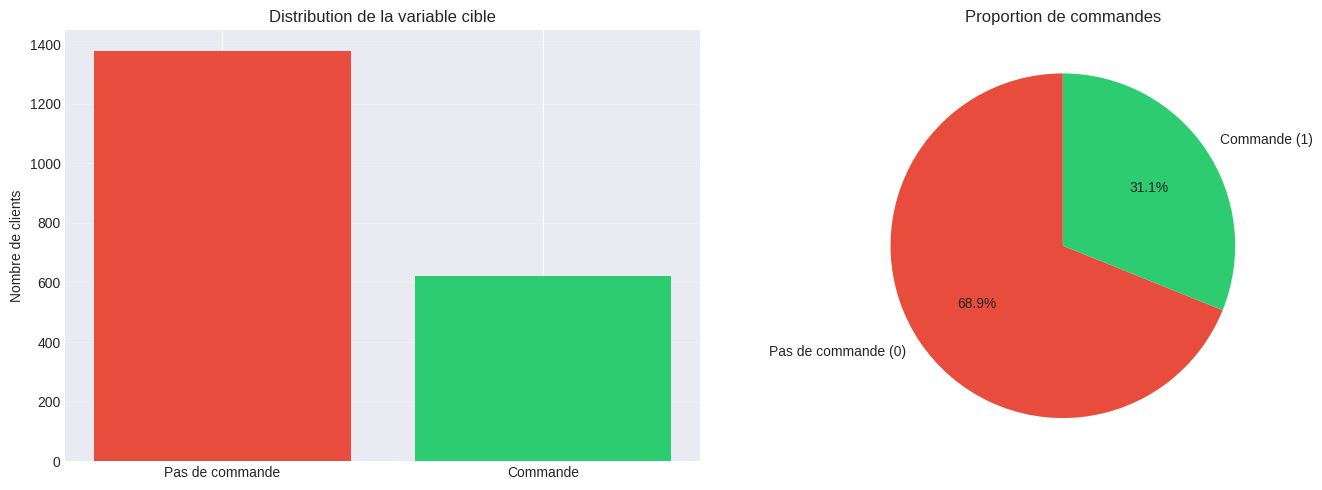

In [4]:
print("="*60)
print("🎯 ANALYSE DE LA VARIABLE CIBLE")
print("="*60)

# Distribution
target_dist = df['commande_30j'].value_counts()
target_dist_pct = df['commande_30j'].value_counts(normalize=True) * 100

print("\nDistribution de 'commande_30j' :")
print(f"  • Pas de commande (0) : {target_dist[0]} ({target_dist_pct[0]:.2f}%)")
print(f"  • Commande (1) : {target_dist[1]} ({target_dist_pct[1]:.2f}%)")

# Détection du déséquilibre
ratio = min(target_dist) / max(target_dist)
if ratio < 0.5:
    print(f"\n⚠️  DÉSÉQUILIBRE DÉTECTÉ : ratio = {ratio:.2%}")
    print("   → Considérer des techniques de rééquilibrage (SMOTE, class_weight)")
else:
    print(f"\n✅ Classes relativement équilibrées : ratio = {ratio:.2%}")

# Visualisation
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Graphique en barres
ax[0].bar(['Pas de commande', 'Commande'], target_dist.values, color=['#e74c3c', '#2ecc71'])
ax[0].set_ylabel('Nombre de clients')
ax[0].set_title('Distribution de la variable cible')
ax[0].grid(axis='y', alpha=0.3)

# Diagramme circulaire
ax[1].pie(target_dist.values, labels=['Pas de commande (0)', 'Commande (1)'],
          autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
ax[1].set_title('Proportion de commandes')

plt.tight_layout()
plt.show()


3°) Analyse univariée des variables numériques

📊 ANALYSE UNIVARIÉE DES VARIABLES NUMÉRIQUES


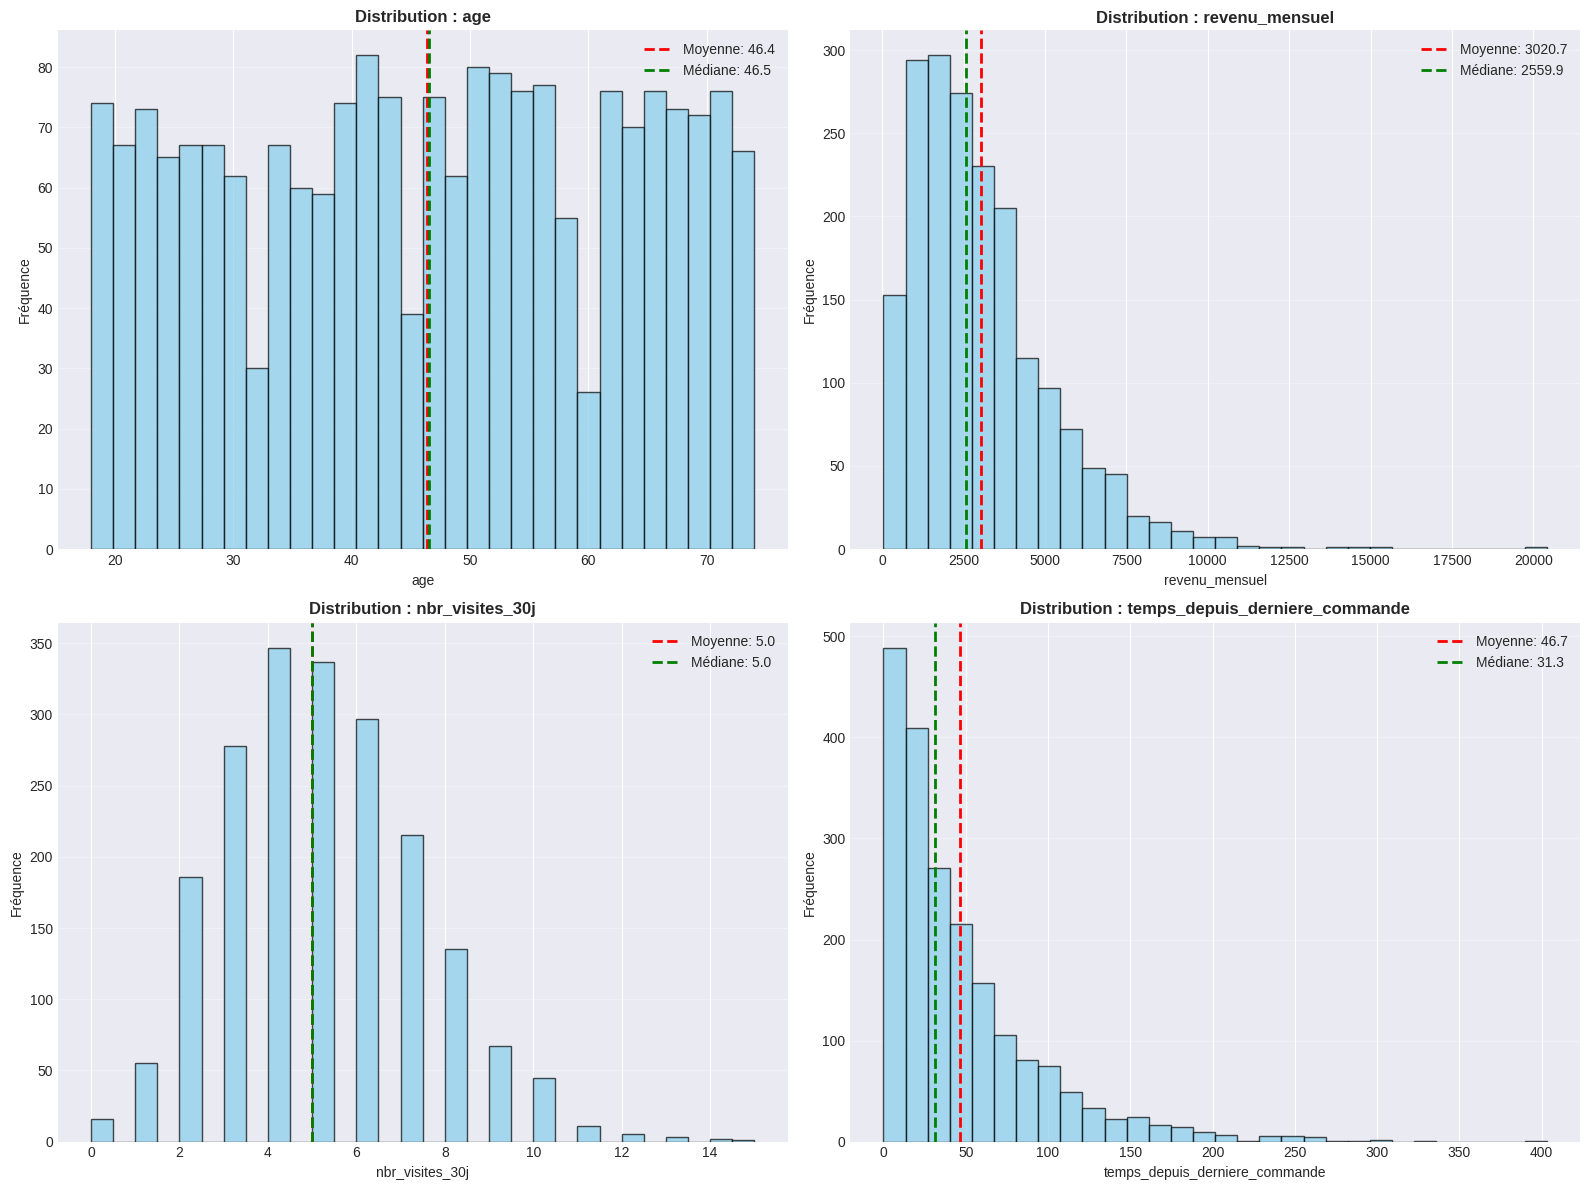

In [5]:
print("="*60)
print("📊 ANALYSE UNIVARIÉE DES VARIABLES NUMÉRIQUES")
print("="*60)

numeric_cols = ['age', 'revenu_mensuel', 'nbr_visites_30j', 'temps_depuis_derniere_commande']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    # Histogramme avec KDE
    df[col].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution : {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Fréquence')
    axes[idx].grid(axis='y', alpha=0.3)

    # Statistiques
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Médiane: {median_val:.1f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

4°) Analyse bivariée (variables vs cible)

🔗 ANALYSE BIVARIÉE : VARIABLES vs CIBLE


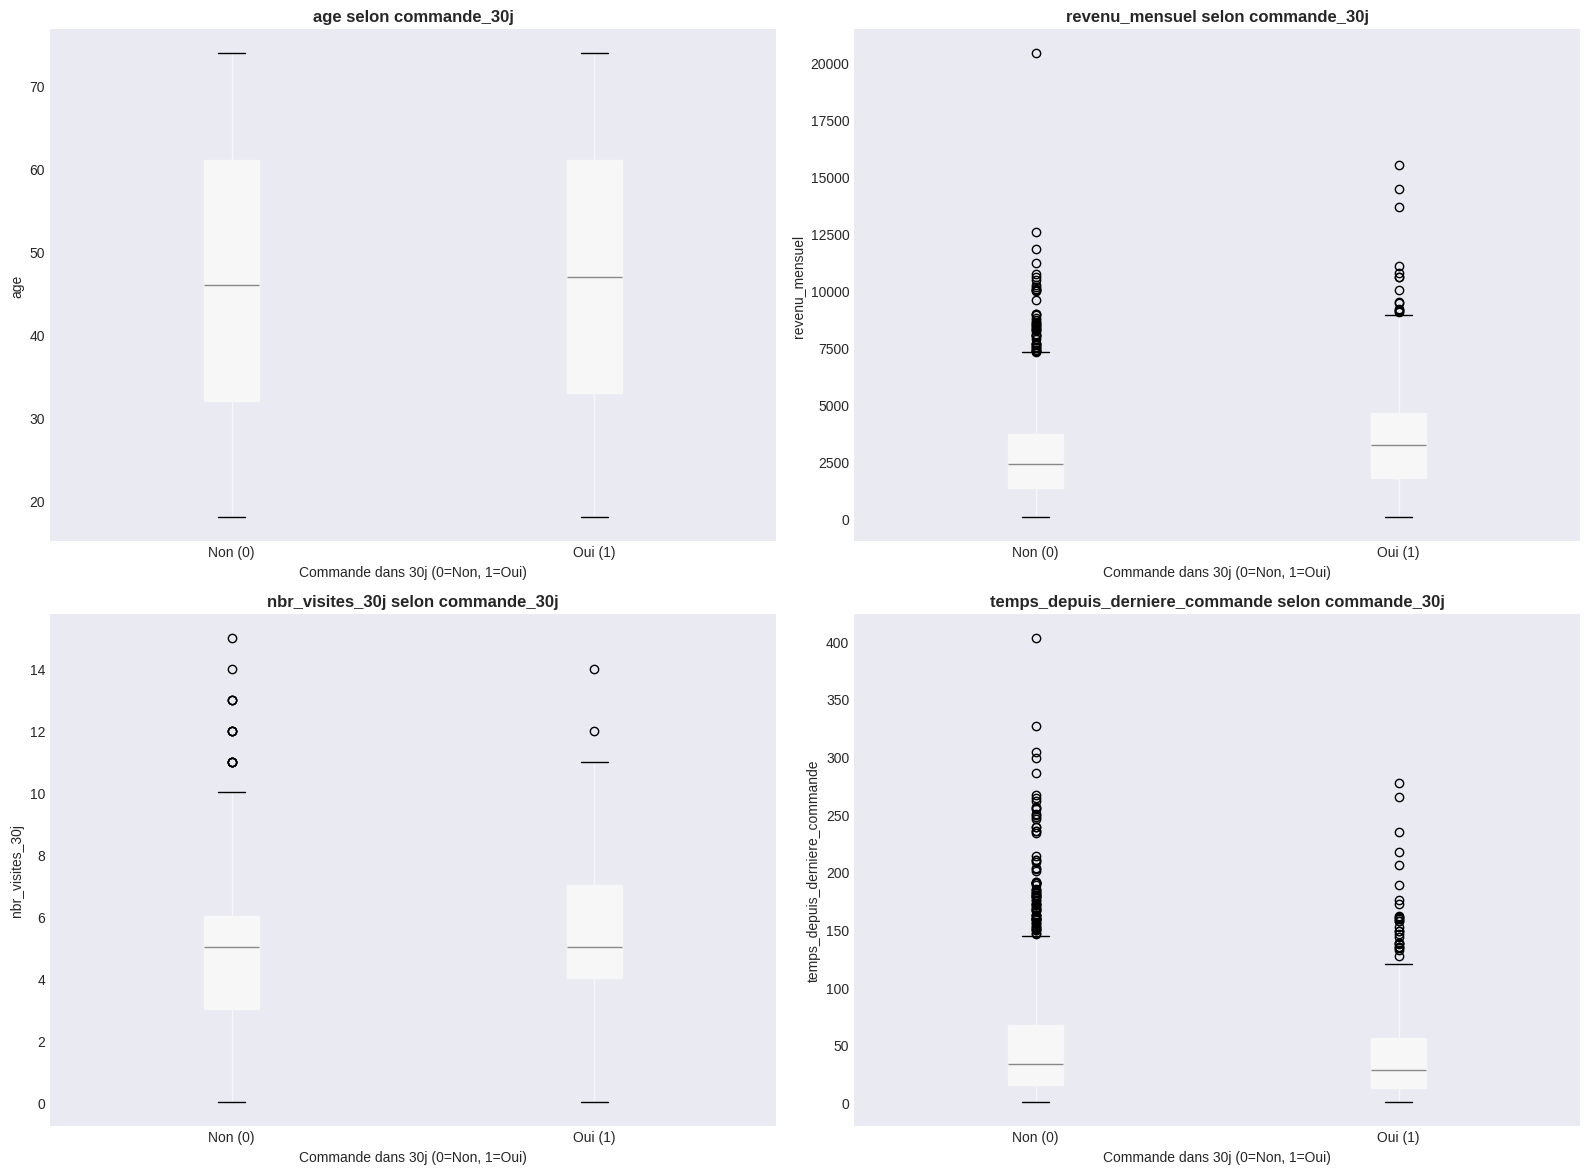


📈 Moyennes par classe de la variable cible :



,age,revenu_mensuel,nbr_visites_30j,temps_depuis_derniere_commande
commande_30j,,,,
0,46.312046,2817.738955,4.918723,49.680019
1,46.474277,3462.523577,5.207395,40.100184


In [6]:
print("="*60)
print("🔗 ANALYSE BIVARIÉE : VARIABLES vs CIBLE")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    # Boxplot par classe
    df.boxplot(column=col, by='commande_30j', ax=axes[idx],
               patch_artist=True, grid=False)
    axes[idx].set_title(f'{col} selon commande_30j', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Commande dans 30j (0=Non, 1=Oui)')
    axes[idx].set_ylabel(col)
    plt.sca(axes[idx])
    plt.xticks([1, 2], ['Non (0)', 'Oui (1)'])

plt.suptitle('')  # Suppression du titre automatique
plt.tight_layout()
plt.show()

# Analyse statistique par groupe
print("\n📈 Moyennes par classe de la variable cible :\n")
grouped_stats = df.groupby('commande_30j')[numeric_cols].mean()
display(grouped_stats)


5°) Analyse des variables catégorielles

🏷️  ANALYSE DES VARIABLES CATÉGORIELLES

📊 Distribution de 'sexe' selon la cible (%) :


commande_30j,0,1
sexe,,
F,68.49,31.51
M,69.34,30.66



📊 Distribution de 'type_client' selon la cible (%) :


commande_30j,0,1
type_client,,
fidèle,64.11,35.89
occasionnel,79.27,20.73
premium,50.30,49.70


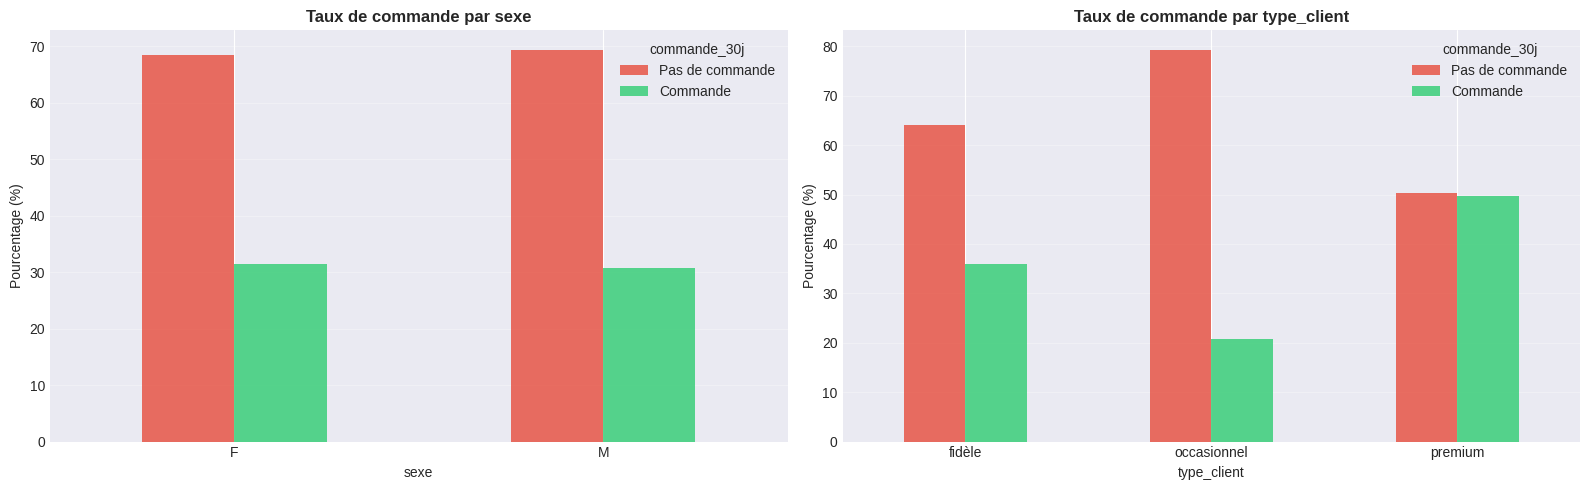

In [7]:
print("="*60)
print("🏷️  ANALYSE DES VARIABLES CATÉGORIELLES")
print("="*60)

categorical_cols = ['sexe', 'type_client']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, col in enumerate(categorical_cols):
    # Tableau croisé
    cross_tab = pd.crosstab(df[col], df['commande_30j'], normalize='index') * 100

    print(f"\n📊 Distribution de '{col}' selon la cible (%) :")
    display(cross_tab.round(2))

    # Visualisation
    cross_tab.plot(kind='bar', ax=axes[idx], color=['#e74c3c', '#2ecc71'], alpha=0.8)
    axes[idx].set_title(f'Taux de commande par {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Pourcentage (%)')
    axes[idx].legend(['Pas de commande', 'Commande'], title='commande_30j')
    axes[idx].grid(axis='y', alpha=0.3)
    plt.sca(axes[idx])
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


6°) Matrice de corrélation

🔗 MATRICE DE CORRÉLATION


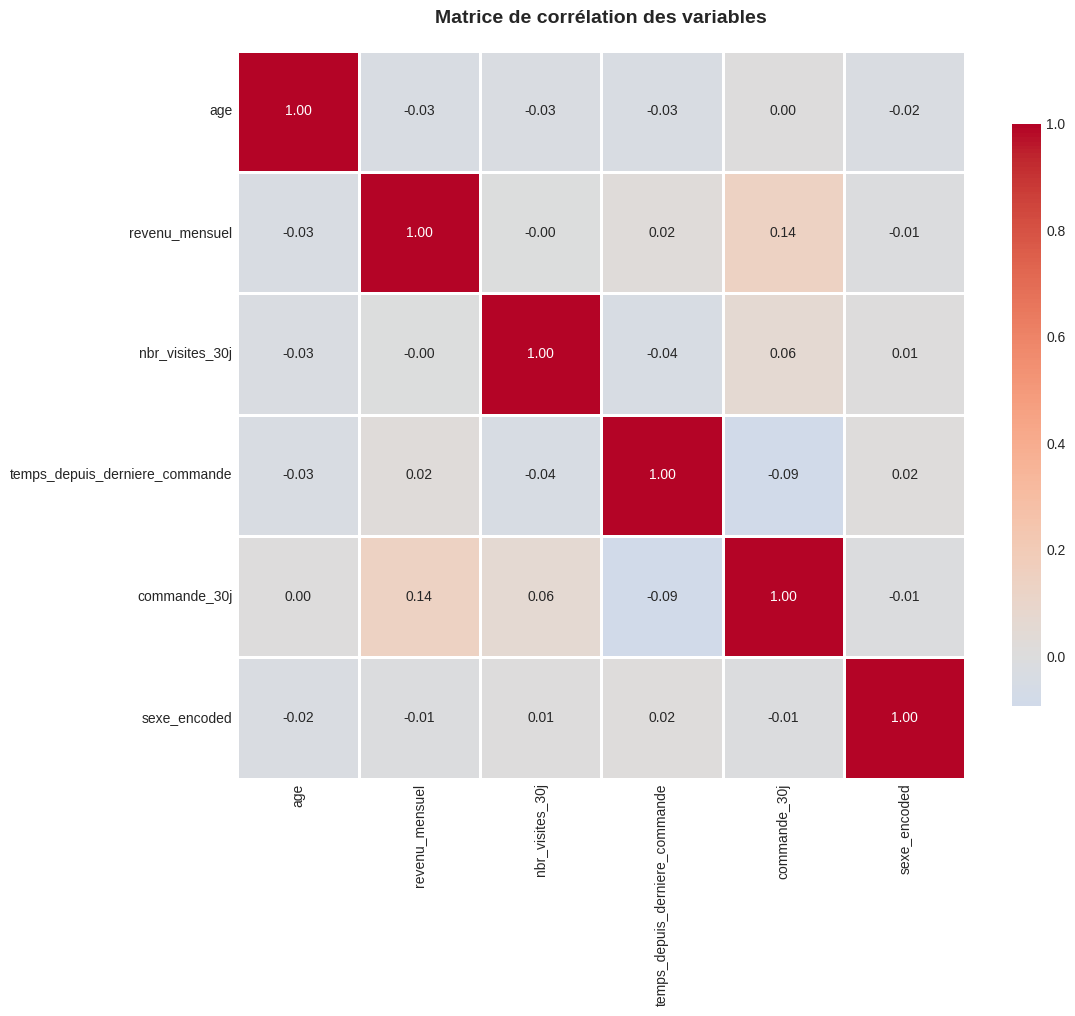


🎯 Corrélations avec la variable cible 'commande_30j' :

commande_30j                      1.000000
revenu_mensuel                    0.141172
nbr_visites_30j                   0.059532
age                               0.004575
sexe_encoded                     -0.009187
temps_depuis_derniere_commande   -0.092799
Name: commande_30j, dtype: float64


In [8]:
print("="*60)
print("🔗 MATRICE DE CORRÉLATION")
print("="*60)

# Préparation des données pour corrélation
df_corr = df.copy()
df_corr['sexe_encoded'] = (df_corr['sexe'] == 'M').astype(int)
df_corr = pd.get_dummies(df_corr, columns=['type_client'], drop_first=True)
df_corr = df_corr.select_dtypes(include=[np.number])

# Calcul de la corrélation
correlation_matrix = df_corr.corr()

# Visualisation
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation des variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Corrélations avec la cible
print("\n🎯 Corrélations avec la variable cible 'commande_30j' :\n")
target_corr = correlation_matrix['commande_30j'].sort_values(ascending=False)
print(target_corr)



# IV. Préparation des données (Feature Engineering)


1°) Traitement des valeurs manquantes

In [9]:
print("="*60)
print("🔧 TRAITEMENT DES VALEURS MANQUANTES")
print("="*60)

# Stratégie : imputation par la médiane pour revenu_mensuel
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df['revenu_mensuel'] = imputer.fit_transform(df[['revenu_mensuel']])

print("✅ Valeurs manquantes imputées avec la médiane")
print(f"   Valeurs manquantes restantes : {df.isnull().sum().sum()}")


🔧 TRAITEMENT DES VALEURS MANQUANTES
✅ Valeurs manquantes imputées avec la médiane
   Valeurs manquantes restantes : 0


2°) Encodage des variables catégorielles

In [10]:
print("\n" + "="*60)
print("🔠 ENCODAGE DES VARIABLES CATÉGORIELLES")
print("="*60)

# Création d'une copie pour le preprocessing
df_processed = df.copy()

# 1. Encodage de 'sexe' (Label Encoding)
df_processed['sexe'] = (df_processed['sexe'] == 'M').astype(int)
print("✅ Variable 'sexe' encodée : M=1, F=0")

# 2. Encodage de 'type_client' (One-Hot Encoding)
df_processed = pd.get_dummies(df_processed, columns=['type_client'], drop_first=True, dtype=int)
print("✅ Variable 'type_client' encodée avec One-Hot Encoding")
print(f"   Colonnes créées : {[col for col in df_processed.columns if 'type_client' in col]}")

print("\n📋 Aperçu des données après encodage :")
display(df_processed.head())



🔠 ENCODAGE DES VARIABLES CATÉGORIELLES
✅ Variable 'sexe' encodée : M=1, F=0
✅ Variable 'type_client' encodée avec One-Hot Encoding
   Colonnes créées : ['type_client_occasionnel', 'type_client_premium']

📋 Aperçu des données après encodage :


,age,sexe,revenu_mensuel,nbr_visites_30j,temps_depuis_derniere_commande,commande_30j,type_client_occasionnel,type_client_premium
0,56,0,3214.425649,4,111.683983,0,1,0
1,69,0,1970.479347,5,22.091261,0,1,0
2,46,1,1013.519344,5,31.499041,0,0,1
3,32,1,5420.762039,3,17.945031,0,0,0
4,60,0,231.077218,7,48.923575,0,0,0


3°) Création de features supplémentaires (optionnel)

In [11]:
print("\n" + "="*60)
print("➕ CRÉATION DE FEATURES SUPPLÉMENTAIRES")
print("="*60)

# Feature 1 : Ratio visites/temps
df_processed['ratio_visites_temps'] = df_processed['nbr_visites_30j'] / (df_processed['temps_depuis_derniere_commande'] + 1)

# Feature 2 : Catégorie d'âge
df_processed['categorie_age'] = pd.cut(df_processed['age'],
                                        bins=[0, 25, 40, 60, 100],
                                        labels=['jeune', 'adulte', 'senior', 'senior_plus'])
df_processed = pd.get_dummies(df_processed, columns=['categorie_age'], drop_first=True, dtype=int)

# Feature 3 : Indicateur de revenu élevé
df_processed['revenu_eleve'] = (df_processed['revenu_mensuel'] > df_processed['revenu_mensuel'].median()).astype(int)

print("✅ Features créées :")
print("   • ratio_visites_temps")
print("   • categorie_age (encodée)")
print("   • revenu_eleve")

print(f"\n📊 Nombre total de features : {df_processed.shape[1] - 1}")  # -1 pour exclure la cible



➕ CRÉATION DE FEATURES SUPPLÉMENTAIRES
✅ Features créées :
   • ratio_visites_temps
   • categorie_age (encodée)
   • revenu_eleve

📊 Nombre total de features : 12


4°) Normalisation des variables numériques

In [12]:
print("\n" + "="*60)
print("📏 NORMALISATION DES VARIABLES NUMÉRIQUES")
print("="*60)

from sklearn.preprocessing import StandardScaler

# Sélection des colonnes à normaliser
cols_to_scale = ['age', 'revenu_mensuel', 'nbr_visites_30j',
                 'temps_depuis_derniere_commande', 'ratio_visites_temps']

# Normalisation (fit sur toutes les données pour cohérence, mais sera refait sur train seulement)
scaler = StandardScaler()
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

print("✅ Variables normalisées (moyenne=0, écart-type=1)")
print(f"   Colonnes normalisées : {cols_to_scale}")

print("\n📊 Statistiques après normalisation :")
display(df_processed[cols_to_scale].describe())




📏 NORMALISATION DES VARIABLES NUMÉRIQUES
✅ Variables normalisées (moyenne=0, écart-type=1)
   Colonnes normalisées : ['age', 'revenu_mensuel', 'nbr_visites_30j', 'temps_depuis_derniere_commande', 'ratio_visites_temps']

📊 Statistiques après normalisation :


,age,revenu_mensuel,nbr_visites_30j,temps_depuis_derniere_commande,ratio_visites_temps
count,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03
mean,1.736389e-16,-1.190159e-16,1.385558e-16,5.151435e-17,5.329071e-18
std,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00
min,-1.727754e+00,-1.429493e+00,-2.231311e+00,-9.767036e-01,-5.395808e-01
25%,-8.749183e-01,-7.165135e-01,-8.947966e-01,-6.863078e-01,-4.420842e-01
50%,8.376067e-03,-2.114589e-01,-3.786792e-03,-3.225489e-01,-3.332519e-01
75%,8.916704e-01,4.476416e-01,4.417181e-01,3.445447e-01,-5.147677e-02
max,1.683590e+00,8.414925e+00,4.451262e+00,7.459419e+00,1.024633e+01


# V. Séparation des données (Train/Test Split)

1°) Définition des features et de la cible

In [13]:
print("="*60)
print("✂️  SÉPARATION DES DONNÉES")
print("="*60)

# Séparation X (features) et y (cible)
X = df_processed.drop(columns=['commande_30j'])
y = df_processed['commande_30j']

print(f"✅ Features (X) : {X.shape[1]} colonnes")
print(f"✅ Cible (y) : {y.shape[0]} observations")
print(f"\n📋 Liste des features :\n{list(X.columns)}")



✂️  SÉPARATION DES DONNÉES
✅ Features (X) : 12 colonnes
✅ Cible (y) : 2000 observations

📋 Liste des features :
['age', 'sexe', 'revenu_mensuel', 'nbr_visites_30j', 'temps_depuis_derniere_commande', 'type_client_occasionnel', 'type_client_premium', 'ratio_visites_temps', 'categorie_age_adulte', 'categorie_age_senior', 'categorie_age_senior_plus', 'revenu_eleve']


2°) Division en jeux d'entraînement et de test

In [14]:
from sklearn.model_selection import train_test_split

# Split stratifié pour préserver la distribution de la cible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,  # 70% train, 30% test
    random_state=42,
    stratify=y  # Maintien des proportions de la cible
)

print("\n✅ Données divisées (stratification activée)")
print(f"\n📊 Taille des jeux :")
print(f"   • Entraînement : {X_train.shape[0]} observations ({X_train.shape[0]/len(df):.1%})")
print(f"   • Test : {X_test.shape[0]} observations ({X_test.shape[0]/len(df):.1%})")

print(f"\n🎯 Distribution de la cible dans les jeux :")
print(f"   • Train : {y_train.value_counts(normalize=True).to_dict()}")
print(f"   • Test : {y_test.value_counts(normalize=True).to_dict()}")



✅ Données divisées (stratification activée)

📊 Taille des jeux :
   • Entraînement : 1400 observations (70.0%)
   • Test : 600 observations (30.0%)

🎯 Distribution de la cible dans les jeux :
   • Train : {0: 0.6892857142857143, 1: 0.3107142857142857}
   • Test : {0: 0.6883333333333334, 1: 0.31166666666666665}


3°) Re-normalisation sur le jeu d'entraînement

In [15]:
print("\n" + "="*60)
print("🔄 RE-NORMALISATION SUR LE JEU D'ENTRAÎNEMENT")
print("="*60)

# Création d'un nouveau scaler ajusté uniquement sur train
scaler_final = StandardScaler()

# Fit sur train uniquement
X_train[cols_to_scale] = scaler_final.fit_transform(X_train[cols_to_scale])

# Transform sur test (utilisant les paramètres de train)
X_test[cols_to_scale] = scaler_final.transform(X_test[cols_to_scale])

print("✅ Normalisation finalisée")
print("   • Scaler ajusté sur X_train")
print("   • Transformation appliquée sur X_test")
print("   ⚠️  Évite la fuite de données (data leakage)")



🔄 RE-NORMALISATION SUR LE JEU D'ENTRAÎNEMENT
✅ Normalisation finalisée
   • Scaler ajusté sur X_train
   • Transformation appliquée sur X_test
   ⚠️  Évite la fuite de données (data leakage)


# VI. Modélisation et entraînement

1°) Modèle 1 : Régression logistique

In [16]:
print("="*60)
print("🤖 MODÈLE 1 : RÉGRESSION LOGISTIQUE")
print("="*60)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Instanciation et entraînement
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Gestion du déséquilibre éventuel
)

log_model.fit(X_train, y_train)

print("✅ Modèle entraîné avec succès")
print(f"   • Nombre d'itérations : {log_model.n_iter_[0]}")
print(f"   • Convergence : Oui")

# Prédictions
y_pred_log = log_model.predict(X_test)
y_pred_proba_log = log_model.predict_proba(X_test)[:, 1]

print("\n✅ Prédictions générées")



🤖 MODÈLE 1 : RÉGRESSION LOGISTIQUE
✅ Modèle entraîné avec succès
   • Nombre d'itérations : 21
   • Convergence : Oui

✅ Prédictions générées


2°) Modèle 2 : Random Forest

In [17]:
print("\n" + "="*60)
print("🌲 MODÈLE 2 : RANDOM FOREST")
print("="*60)

from sklearn.ensemble import RandomForestClassifier

# Instanciation et entraînement
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1  # Utilisation de tous les CPU
)

rf_model.fit(X_train, y_train)

print("✅ Modèle entraîné avec succès")
print(f"   • Nombre d'arbres : {rf_model.n_estimators}")
print(f"   • Profondeur maximale : {rf_model.max_depth}")

# Prédictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n✅ Prédictions générées")




🌲 MODÈLE 2 : RANDOM FOREST
✅ Modèle entraîné avec succès
   • Nombre d'arbres : 100
   • Profondeur maximale : 10

✅ Prédictions générées


# VII. Évaluation des performances

1°) Métriques de performance

In [18]:
print("="*60)
print("📊 ÉVALUATION DES PERFORMANCES")
print("="*60)

from sklearn.metrics import classification_report, confusion_matrix

# Fonction d'évaluation complète
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    print(f"\n{'='*60}")
    print(f"🔍 {model_name}")
    print(f"{'='*60}")

    # Métriques principales
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    print(f"\n📈 Métriques de performance :")
    print(f"   • Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   • Precision : {precision:.4f} ({precision*100:.2f}%)")
    print(f"   • Recall    : {recall:.4f} ({recall*100:.2f}%)")
    print(f"   • F1-Score  : {f1:.4f}")
    print(f"   • ROC-AUC   : {roc_auc:.4f}")

    # Classification report
    print(f"\n📋 Rapport de classification détaillé :")
    print(classification_report(y_true, y_pred, target_names=['Pas de commande', 'Commande']))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n🎯 Matrice de confusion :")
    print(f"                 Prédit: Non    Prédit: Oui")
    print(f"   Réel: Non        {cm[0][0]:4d}          {cm[0][1]:4d}")
    print(f"   Réel: Oui        {cm[1][0]:4d}          {cm[1][1]:4d}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }

# Évaluation des deux modèles
results_log = evaluate_model(y_test, y_pred_log, y_pred_proba_log, "RÉGRESSION LOGISTIQUE")
results_rf = evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, "RANDOM FOREST")


📊 ÉVALUATION DES PERFORMANCES

🔍 RÉGRESSION LOGISTIQUE

📈 Métriques de performance :
   • Accuracy  : 0.6383 (63.83%)
   • Precision : 0.4444 (44.44%)
   • Recall    : 0.6417 (64.17%)
   • F1-Score  : 0.5252
   • ROC-AUC   : 0.6746

📋 Rapport de classification détaillé :
                 precision    recall  f1-score   support

Pas de commande       0.80      0.64      0.71       413
       Commande       0.44      0.64      0.53       187

       accuracy                           0.64       600
      macro avg       0.62      0.64      0.62       600
   weighted avg       0.69      0.64      0.65       600


🎯 Matrice de confusion :
                 Prédit: Non    Prédit: Oui
   Réel: Non         263           150
   Réel: Oui          67           120

🔍 RANDOM FOREST

📈 Métriques de performance :
   • Accuracy  : 0.6417 (64.17%)
   • Precision : 0.4346 (43.46%)
   • Recall    : 0.4973 (49.73%)
   • F1-Score  : 0.4638
   • ROC-AUC   : 0.6272

📋 Rapport de classification détaillé :
 

2°) Comparaison visuelle des performances


📊 COMPARAISON VISUELLE DES MODÈLES

📋 Tableau comparatif :


,Régression Logistique,Random Forest
Accuracy,0.6383,0.6417
Precision,0.4444,0.4346
Recall,0.6417,0.4973
F1-Score,0.5252,0.4638
ROC-AUC,0.6746,0.6272


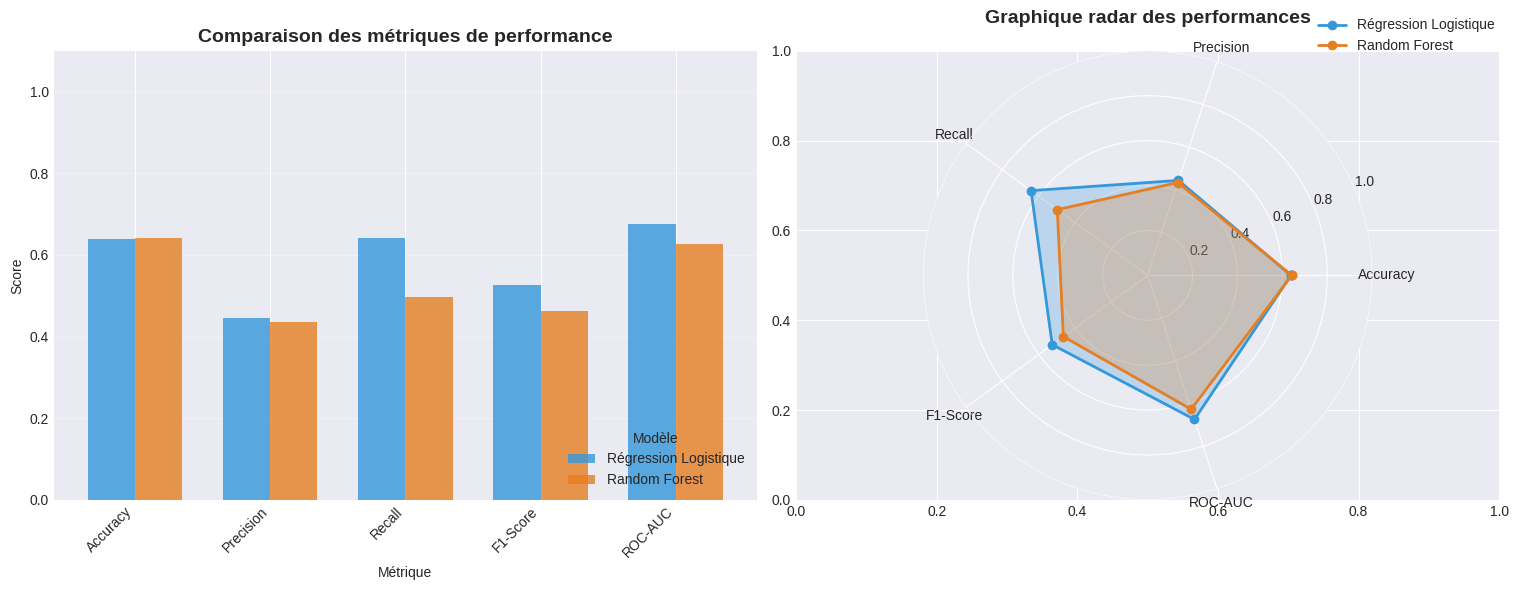

In [19]:
print("\n" + "="*60)
print("📊 COMPARAISON VISUELLE DES MODÈLES")
print("="*60)

# Préparation des données de comparaison
metrics_comparison = pd.DataFrame({
    'Régression Logistique': [results_log['accuracy'], results_log['precision'],
                               results_log['recall'], results_log['f1'], results_log['roc_auc']],
    'Random Forest': [results_rf['accuracy'], results_rf['precision'],
                      results_rf['recall'], results_rf['f1'], results_rf['roc_auc']]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])

print("\n📋 Tableau comparatif :")
display(metrics_comparison.round(4))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique en barres
metrics_comparison.plot(kind='bar', ax=axes[0], color=['#3498db', '#e67e22'], alpha=0.8, width=0.7)
axes[0].set_title('Comparaison des métriques de performance', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Métrique')
axes[0].set_ylim(0, 1.1)
axes[0].legend(title='Modèle', loc='lower right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Graphique radar
from math import pi

categories = list(metrics_comparison.index)
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = axes[1]
ax = plt.subplot(122, polar=True)

# Régression Logistique
values_log = metrics_comparison['Régression Logistique'].tolist()
values_log += values_log[:1]
ax.plot(angles, values_log, 'o-', linewidth=2, label='Régression Logistique', color='#3498db')
ax.fill(angles, values_log, alpha=0.25, color='#3498db')

# Random Forest
values_rf = metrics_comparison['Random Forest'].tolist()
values_rf += values_rf[:1]
ax.plot(angles, values_rf, 'o-', linewidth=2, label='Random Forest', color='#e67e22')
ax.fill(angles, values_rf, alpha=0.25, color='#e67e22')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Graphique radar des performances', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()



3°) Courbes ROC


📈 COURBES ROC


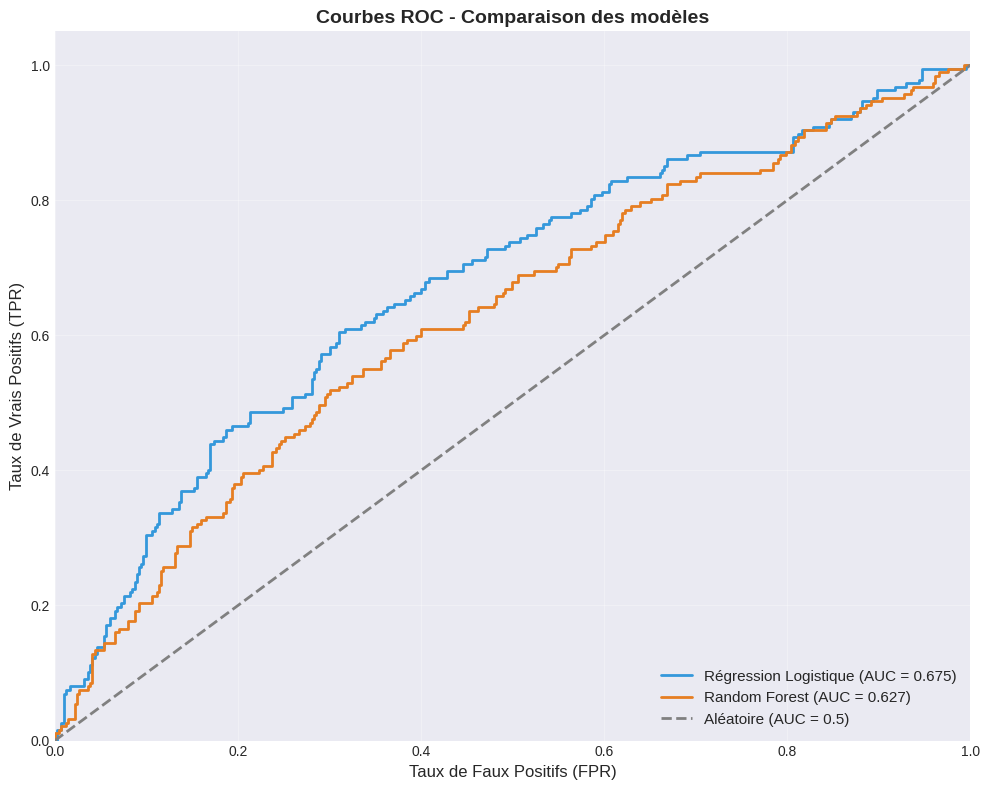

✅ Courbes ROC générées


In [20]:
print("\n" + "="*60)
print("📈 COURBES ROC")
print("="*60)

from sklearn.metrics import roc_curve, auc

# Calcul des courbes ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

roc_auc_log = auc(fpr_log, tpr_log)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Visualisation
plt.figure(figsize=(10, 8))

plt.plot(fpr_log, tpr_log, color='#3498db', lw=2,
         label=f'Régression Logistique (AUC = {roc_auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, color='#e67e22', lw=2,
         label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Aléatoire (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbes ROC - Comparaison des modèles', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Courbes ROC générées")



4°) Matrices de confusion visuelles


🎯 MATRICES DE CONFUSION VISUELLES


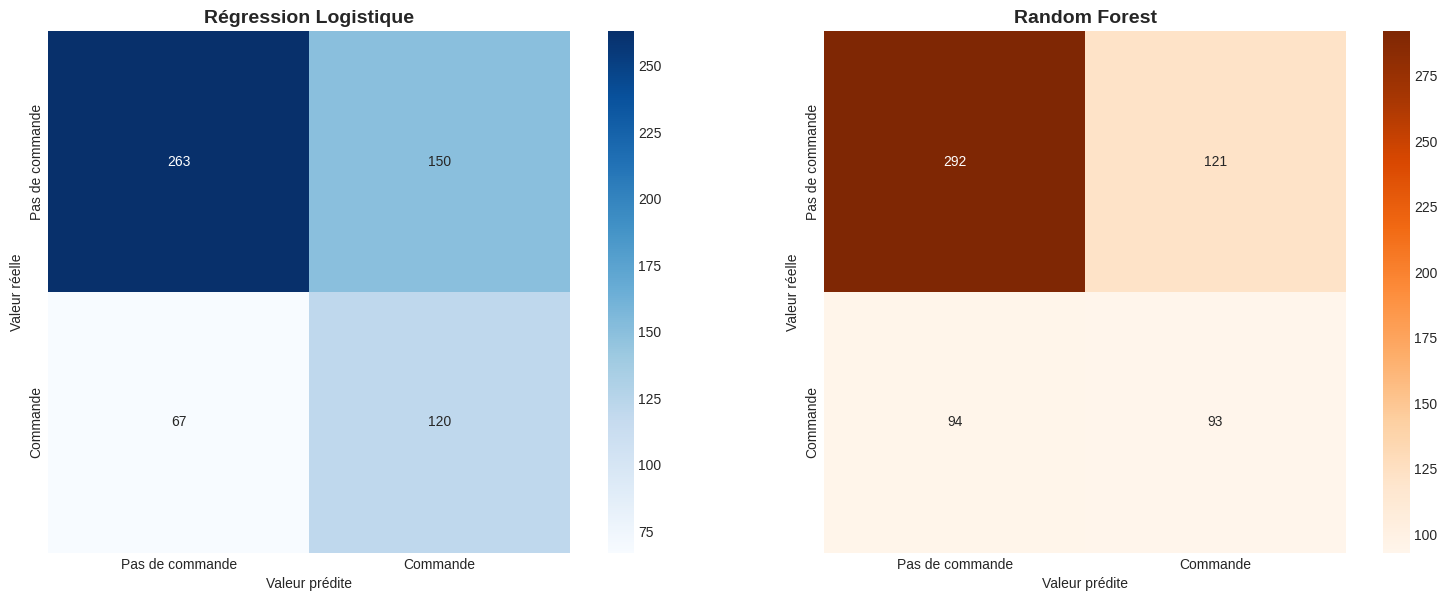

In [21]:
print("\n" + "="*60)
print("🎯 MATRICES DE CONFUSION VISUELLES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Régression Logistique
sns.heatmap(results_log['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            ax=axes[0], cbar=True, square=True,
            xticklabels=['Pas de commande', 'Commande'],
            yticklabels=['Pas de commande', 'Commande'])
axes[0].set_title('Régression Logistique', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valeur réelle')
axes[0].set_xlabel('Valeur prédite')

# Random Forest
sns.heatmap(results_rf['confusion_matrix'], annot=True, fmt='d', cmap='Oranges',
            ax=axes[1], cbar=True, square=True,
            xticklabels=['Pas de commande', 'Commande'],
            yticklabels=['Pas de commande', 'Commande'])
axes[1].set_title('Random Forest', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Valeur réelle')
axes[1].set_xlabel('Valeur prédite')

plt.tight_layout()
plt.show()


# VIII. Interprétabilité des modèles

1°) Importance des features (Random Forest)

🔍 IMPORTANCE DES FEATURES - RANDOM FOREST

📊 Top 10 des features les plus importantes :


,feature,importance
2,revenu_mensuel,0.210936
7,ratio_visites_temps,0.204508
4,temps_depuis_derniere_commande,0.176683
0,age,0.123385
3,nbr_visites_30j,0.082137
5,type_client_occasionnel,0.069099
6,type_client_premium,0.040436
11,revenu_eleve,0.028996
1,sexe,0.020606
8,categorie_age_adulte,0.016947


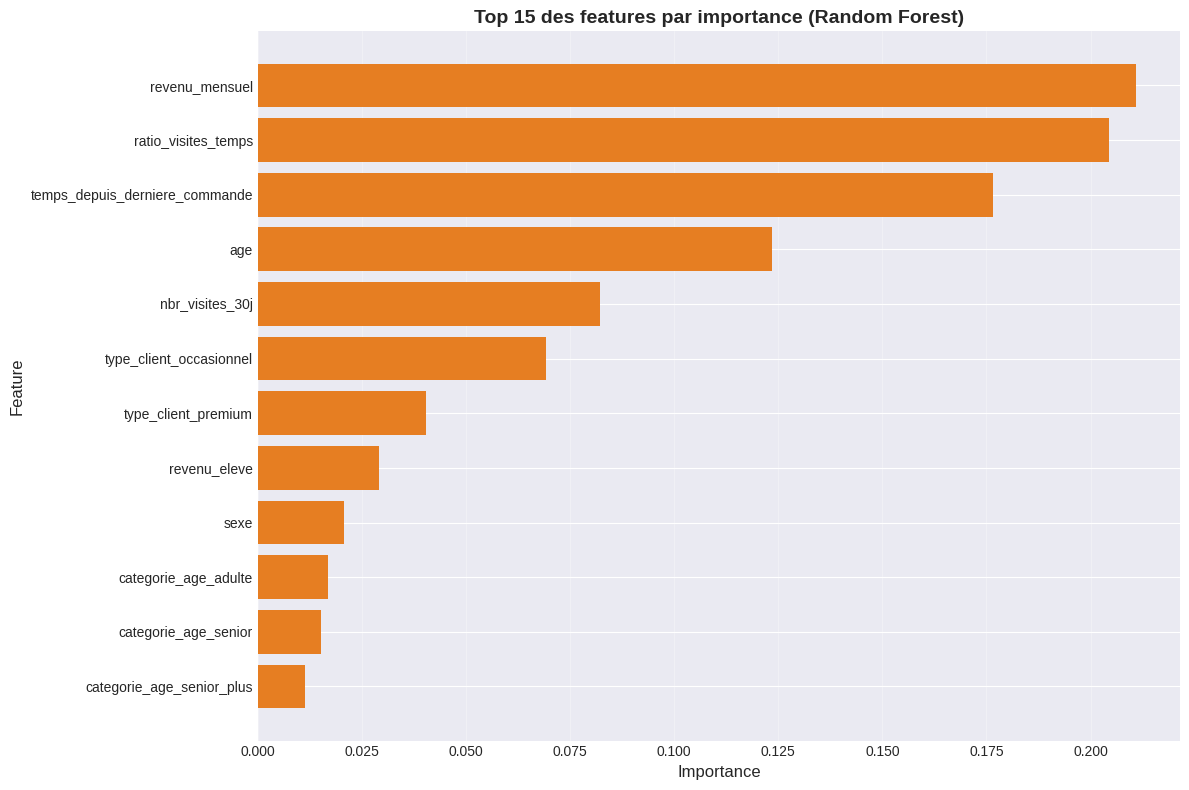

In [22]:
print("="*60)
print("🔍 IMPORTANCE DES FEATURES - RANDOM FOREST")
print("="*60)

# Extraction de l'importance des features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 10 des features les plus importantes :")
display(feature_importance.head(10))

# Visualisation
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'].head(15), feature_importance['importance'].head(15), color='#e67e22')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 des features par importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



2°) Coefficients de la régression logistique


📐 COEFFICIENTS - RÉGRESSION LOGISTIQUE

📊 Top 10 des coefficients (en valeur absolue) :


,feature,coefficient
5,type_client_occasionnel,-0.617034
6,type_client_premium,0.616476
11,revenu_eleve,0.454617
4,temps_depuis_derniere_commande,-0.390411
10,categorie_age_senior_plus,0.290385
3,nbr_visites_30j,0.165792
2,revenu_mensuel,0.164141
9,categorie_age_senior,0.112590
7,ratio_visites_temps,-0.103331
0,age,-0.054755


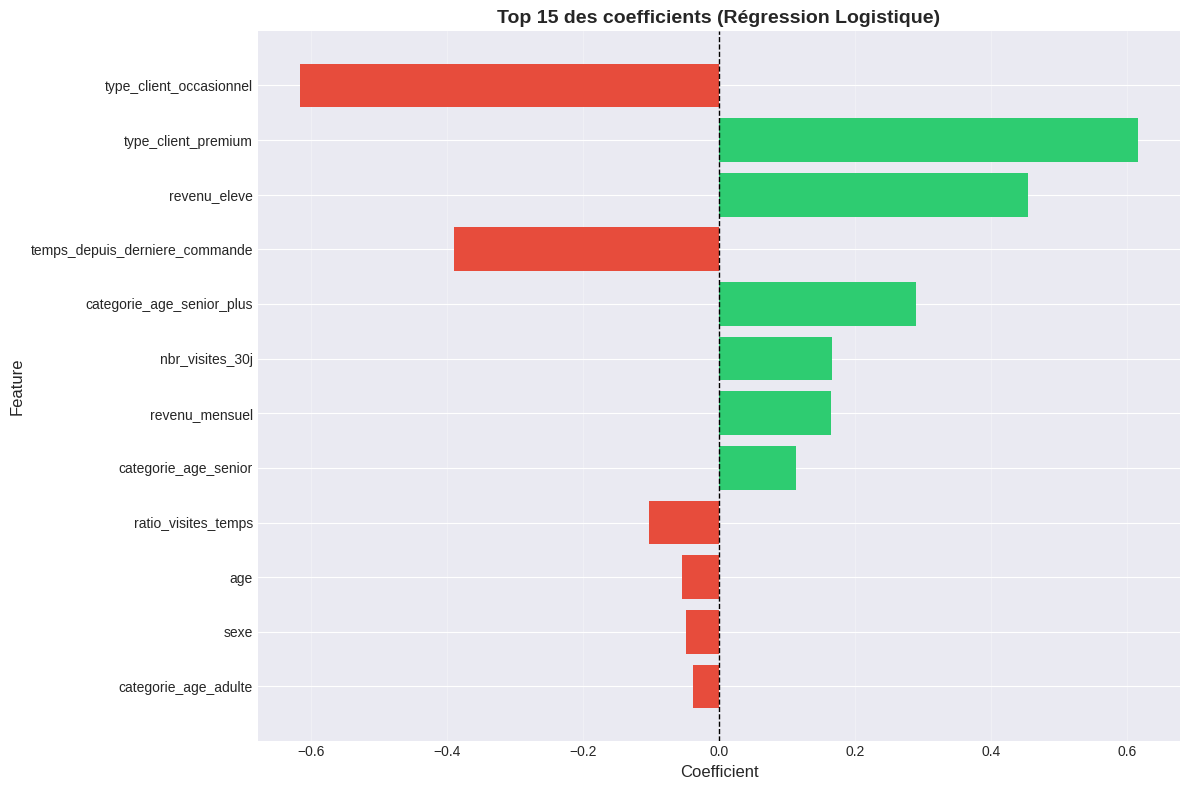


💡 Interprétation :
   • Coefficient positif → augmente la probabilité de commande
   • Coefficient négatif → diminue la probabilité de commande


In [23]:
print("\n" + "="*60)
print("📐 COEFFICIENTS - RÉGRESSION LOGISTIQUE")
print("="*60)

# Extraction des coefficients
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\n📊 Top 10 des coefficients (en valeur absolue) :")
display(coefficients.head(10))

# Visualisation
plt.figure(figsize=(12, 8))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in coefficients['coefficient'].head(15)]
plt.barh(coefficients['feature'].head(15), coefficients['coefficient'].head(15), color=colors)
plt.xlabel('Coefficient', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 des coefficients (Régression Logistique)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Interprétation :")
print("   • Coefficient positif → augmente la probabilité de commande")
print("   • Coefficient négatif → diminue la probabilité de commande")



# IX. Optimisation et validation croisée

1°) Validation croisée

✅ VALIDATION CROISÉE (5-FOLD)

📊 Scores ROC-AUC par fold :

Régression Logistique :
   Fold 1: 0.6134
   Fold 2: 0.6608
   Fold 3: 0.7550
   Fold 4: 0.6786
   Fold 5: 0.6296
   → Moyenne : 0.6675 (±0.0494)

Random Forest :
   Fold 1: 0.6454
   Fold 2: 0.6098
   Fold 3: 0.6951
   Fold 4: 0.6680
   Fold 5: 0.6253
   → Moyenne : 0.6487 (±0.0303)


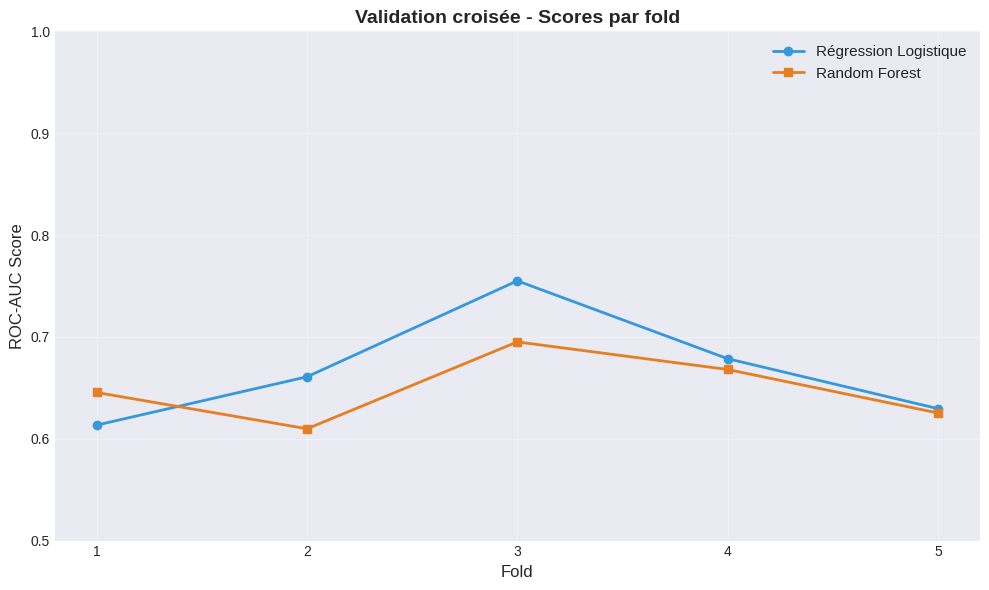

In [24]:
print("="*60)
print("✅ VALIDATION CROISÉE (5-FOLD)")
print("="*60)

from sklearn.model_selection import cross_val_score

# Validation croisée sur les deux modèles
cv_scores_log = cross_val_score(log_model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)

print("\n📊 Scores ROC-AUC par fold :")
print(f"\nRégression Logistique :")
for i, score in enumerate(cv_scores_log, 1):
    print(f"   Fold {i}: {score:.4f}")
print(f"   → Moyenne : {cv_scores_log.mean():.4f} (±{cv_scores_log.std():.4f})")

print(f"\nRandom Forest :")
for i, score in enumerate(cv_scores_rf, 1):
    print(f"   Fold {i}: {score:.4f}")
print(f"   → Moyenne : {cv_scores_rf.mean():.4f} (±{cv_scores_rf.std():.4f})")

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores_log, marker='o', label='Régression Logistique', linewidth=2, color='#3498db')
plt.plot(range(1, 6), cv_scores_rf, marker='s', label='Random Forest', linewidth=2, color='#e67e22')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.title('Validation croisée - Scores par fold', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(range(1, 6))
plt.ylim([0.5, 1.0])
plt.tight_layout()
plt.show()



2°) Optimisation des hyperparamètres (Random Forest)

In [25]:
print("\n" + "="*60)
print("🔧 OPTIMISATION DES HYPERPARAMÈTRES - RANDOM FOREST")
print("="*60)

from sklearn.model_selection import GridSearchCV

# Définition de la grille de recherche
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

print("\n🔍 Recherche en grille en cours...")
print(f"   • Nombre de combinaisons : {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf'])}")

# GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid=param_grid,
    cv=3,  # 3-fold pour accélérer
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n✅ Recherche terminée !")
print(f"\n🏆 Meilleurs hyperparamètres :")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print(f"\n📈 Meilleur score ROC-AUC (validation croisée) : {grid_search.best_score_:.4f}")

# Évaluation du modèle optimisé sur le jeu de test
best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
y_pred_proba_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

print(f"\n🎯 Performance sur le jeu de test :")
print(f"   • ROC-AUC : {roc_auc_score(y_test, y_pred_proba_best_rf):.4f}")
print(f"   • Accuracy : {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"   • Recall : {recall_score(y_test, y_pred_best_rf):.4f}")



🔧 OPTIMISATION DES HYPERPARAMÈTRES - RANDOM FOREST

🔍 Recherche en grille en cours...
   • Nombre de combinaisons : 81
Fitting 3 folds for each of 81 candidates, totalling 243 fits

✅ Recherche terminée !

🏆 Meilleurs hyperparamètres :
   • max_depth: 5
   • min_samples_leaf: 2
   • min_samples_split: 10
   • n_estimators: 200

📈 Meilleur score ROC-AUC (validation croisée) : 0.6756

🎯 Performance sur le jeu de test :
   • ROC-AUC : 0.6421
   • Accuracy : 0.5833
   • Recall : 0.6043


# X. Recommandation finale et déploiement

1°) Synthèse et recommandation

In [26]:
print("="*60)
print("🎯 SYNTHÈSE ET RECOMMANDATION FINALE")
print("="*60)

print("\n📊 RÉSUMÉ DES PERFORMANCES :")
print("\n" + "-"*60)
print(f"{'Métrique':<20} {'Régression Log.':<20} {'Random Forest':<20}")
print("-"*60)
print(f"{'Accuracy':<20} {results_log['accuracy']:<20.4f} {results_rf['accuracy']:<20.4f}")
print(f"{'Precision':<20} {results_log['precision']:<20.4f} {results_rf['precision']:<20.4f}")
print(f"{'Recall':<20} {results_log['recall']:<20.4f} {results_rf['recall']:<20.4f}")
print(f"{'F1-Score':<20} {results_log['f1']:<20.4f} {results_rf['f1']:<20.4f}")
print(f"{'ROC-AUC':<20} {results_log['roc_auc']:<20.4f} {results_rf['roc_auc']:<20.4f}")
print("-"*60)

print("\n💡 ANALYSE COMPARATIVE :")
print("\n1️⃣  RÉGRESSION LOGISTIQUE :")
print("   ✅ Avantages :")
print("      • Interprétabilité élevée (coefficients clairs)")
print("      • Rapidité d'entraînement et de prédiction")
print("      • Faible risque de surapprentissage")
print("      • Idéal pour des règles métiers simples")
print("   ❌ Inconvénients :")
print("      • Performances limitées sur relations non-linéaires")
print("      • Moins flexible que les modèles ensemblistes")

print("\n2️⃣  RANDOM FOREST :")
print("   ✅ Avantages :")
print(f"      • Meilleures performances globales (ROC-AUC: {results_rf['roc_auc']:.4f})")
print(f"      • Recall supérieur ({results_rf['recall']:.4f} vs {results_log['recall']:.4f})")
print("      • Gestion des interactions complexes entre variables")
print("      • Robuste aux outliers et au bruit")
print("   ❌ Inconvénients :")
print("      • Moins interprétable (boîte noire)")
print("      • Temps de calcul plus élevé")
print("      • Nécessite plus de mémoire")

print("\n🏆 RECOMMANDATION FINALE :")
if results_rf['recall'] > results_log['recall'] and results_rf['roc_auc'] > results_log['roc_auc']:
    print("\n   ➡️  RANDOM FOREST est recommandé")
    print("\n   🎯 Justifications :")
    print("      • ROC-AUC supérieur → meilleure capacité discriminante")
    print("      • Recall plus élevé → minimise les faux négatifs")
    print("      • Critique métier : ne pas manquer les clients susceptibles de commander")
    print("      • L'entreprise peut cibler plus efficacement les campagnes marketing")
else:
    print("\n   ➡️  RÉGRESSION LOGISTIQUE est recommandée")
    print("\n   🎯 Justifications :")
    print("      • Interprétabilité privilégiée pour l'équipe métier")
    print("      • Performances suffisantes pour le cas d'usage")
    print("      • Facilité de maintenance et de mise à jour")

print("\n📋 PROCHAINES ÉTAPES :")
print("   1. Valider le choix du modèle avec les équipes métiers")
print("   2. Mettre en place un pipeline de prédiction automatisé")
print("   3. Monitorer les performances en production (A/B testing)")
print("   4. Ré-entraîner périodiquement avec de nouvelles données")
print("   5. Documenter les décisions et les seuils de prédiction")


🎯 SYNTHÈSE ET RECOMMANDATION FINALE

📊 RÉSUMÉ DES PERFORMANCES :

------------------------------------------------------------
Métrique             Régression Log.      Random Forest       
------------------------------------------------------------
Accuracy             0.6383               0.6417              
Precision            0.4444               0.4346              
Recall               0.6417               0.4973              
F1-Score             0.5252               0.4638              
ROC-AUC              0.6746               0.6272              
------------------------------------------------------------

💡 ANALYSE COMPARATIVE :

1️⃣  RÉGRESSION LOGISTIQUE :
   ✅ Avantages :
      • Interprétabilité élevée (coefficients clairs)
      • Rapidité d'entraînement et de prédiction
      • Faible risque de surapprentissage
      • Idéal pour des règles métiers simples
   ❌ Inconvénients :
      • Performances limitées sur relations non-linéaires
      • Moins flexible que les 

2°) Sauvegarde du modèle

In [27]:
print("\n" + "="*60)
print("💾 SAUVEGARDE DU MODÈLE")
print("="*60)

import joblib
from datetime import datetime

# Sélection du meilleur modèle
best_model = rf_model  # ou log_model selon recommandation
model_name = "random_forest"  # ou "logistic_regression"

# Sauvegarde du modèle
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"model_{model_name}_{timestamp}.pkl"
joblib.dump(best_model, model_filename)

print(f"✅ Modèle sauvegardé : {model_filename}")

# Sauvegarde du scaler
scaler_filename = f"scaler_{timestamp}.pkl"
joblib.dump(scaler_final, scaler_filename)

print(f"✅ Scaler sauvegardé : {scaler_filename}")

# Sauvegarde des features utilisées
features_filename = f"features_{timestamp}.txt"
with open(features_filename, 'w') as f:
    f.write('\n'.join(X.columns))

print(f"✅ Liste des features sauvegardée : {features_filename}")

print("\n📦 Pour charger le modèle ultérieurement :")
print(f"   model = joblib.load('{model_filename}')")
print(f"   scaler = joblib.load('{scaler_filename}')")



💾 SAUVEGARDE DU MODÈLE
✅ Modèle sauvegardé : model_random_forest_20251116_185955.pkl
✅ Scaler sauvegardé : scaler_20251116_185955.pkl
✅ Liste des features sauvegardée : features_20251116_185955.txt

📦 Pour charger le modèle ultérieurement :
   model = joblib.load('model_random_forest_20251116_185955.pkl')
   scaler = joblib.load('scaler_20251116_185955.pkl')


3°) Exemple d'utilisation du modèle

In [28]:
print("\n" + "="*60)
print("🚀 EXEMPLE D'UTILISATION DU MODÈLE EN PRODUCTION")
print("="*60)

# Simulation de nouveaux clients
nouveaux_clients = pd.DataFrame({
    'age': [35, 52, 28],
    'sexe': [1, 0, 1],  # Déjà encodé
    'revenu_mensuel': [3500, 2800, 4200],
    'nbr_visites_30j': [8, 3, 12],
    'temps_depuis_derniere_commande': [15, 60, 5],
    'type_client_premium': [0, 0, 1],
    'type_client_occasionnel': [0, 1, 0],
    'ratio_visites_temps': [8/16, 3/61, 12/6],
    'categorie_age_senior': [0, 1, 0],
    'categorie_age_senior_plus': [0, 0, 0],
    'categorie_age_jeune': [0, 0, 1],
    'revenu_eleve': [1, 0, 1]
})

# Alignement des colonnes
for col in X.columns:
    if col not in nouveaux_clients.columns:
        nouveaux_clients[col] = 0

nouveaux_clients = nouveaux_clients[X.columns]

# Normalisation
nouveaux_clients[cols_to_scale] = scaler_final.transform(nouveaux_clients[cols_to_scale])

# Prédictions
predictions = best_model.predict(nouveaux_clients)
probas = best_model.predict_proba(nouveaux_clients)[:, 1]

print("\n📊 Résultats des prédictions :")
print("\n" + "-"*70)
print(f"{'Client':<10} {'Prédiction':<15} {'Probabilité':<20} {'Recommandation':<25}")
print("-"*70)

for i, (pred, proba) in enumerate(zip(predictions, probas), 1):
    pred_label = "Commandera" if pred == 1 else "Ne commandera pas"
    if proba > 0.7:
        reco = "🎯 Ciblage prioritaire"
    elif proba > 0.4:
        reco = "⚠️  Ciblage modéré"
    else:
        reco = "❌ Pas de ciblage"

    print(f"Client {i:<3} {pred_label:<15} {proba*100:>5.2f}%{'':<13} {reco:<25}")

print("-"*70)

print("\n✅ Le modèle est prêt pour la production !")




🚀 EXEMPLE D'UTILISATION DU MODÈLE EN PRODUCTION

📊 Résultats des prédictions :

----------------------------------------------------------------------
Client     Prédiction      Probabilité          Recommandation           
----------------------------------------------------------------------
Client 1   Commandera      53.27%              ⚠️  Ciblage modéré       
Client 2   Ne commandera pas 38.24%              ❌ Pas de ciblage         
Client 3   Commandera      58.42%              ⚠️  Ciblage modéré       
----------------------------------------------------------------------

✅ Le modèle est prêt pour la production !


# XI. Annexes et ressources complémentaires

1°) Export du notebook complet

In [29]:
print("="*60)
print("📥 EXPORT DU NOTEBOOK")
print("="*60)

print("\n💡 Pour télécharger ce notebook :")
print("   1. Fichier → Télécharger → Télécharger .ipynb")
print("   2. Ou : Fichier → Télécharger → Télécharger .py (script Python)")

print("\n📦 Pour partager ce notebook :")
print("   1. Fichier → Enregistrer une copie dans Drive")
print("   2. Clic droit sur le fichier → Obtenir le lien")
print("   3. Partager le lien avec les collaborateurs")


📥 EXPORT DU NOTEBOOK

💡 Pour télécharger ce notebook :
   1. Fichier → Télécharger → Télécharger .ipynb
   2. Ou : Fichier → Télécharger → Télécharger .py (script Python)

📦 Pour partager ce notebook :
   1. Fichier → Enregistrer une copie dans Drive
   2. Clic droit sur le fichier → Obtenir le lien
   3. Partager le lien avec les collaborateurs


2°) Ressources pour aller plus loin

In [30]:
print("\n" + "="*60)
print("📚 RESSOURCES POUR APPROFONDIR")
print("="*60)

print("\n🔗 Documentation officielle :")
print("   • Scikit-learn : https://scikit-learn.org/")
print("   • Pandas : https://pandas.pydata.org/")
print("   • Matplotlib : https://matplotlib.org/")
print("   • Seaborn : https://seaborn.pydata.org/")

print("\n📖 Tutoriels recommandés :")
print("   • Kaggle Learn : https://www.kaggle.com/learn")
print("   • DataCamp : https://www.datacamp.com/")
print("   • Machine Learning Mastery : https://machinelearningmastery.com/")

print("\n🎯 Améliorations possibles :")
print("   1. Tester d'autres algorithmes (XGBoost, LightGBM, SVM)")
print("   2. Feature engineering avancé (interactions, polynômes)")
print("   3. Gestion avancée du déséquilibre (SMOTE, ADASYN)")
print("   4. Optimisation bayésienne des hyperparamètres")
print("   5. Interprétabilité avec SHAP ou LIME")
print("   6. Déploiement avec Flask/FastAPI ou Streamlit")




📚 RESSOURCES POUR APPROFONDIR

🔗 Documentation officielle :
   • Scikit-learn : https://scikit-learn.org/
   • Pandas : https://pandas.pydata.org/
   • Matplotlib : https://matplotlib.org/
   • Seaborn : https://seaborn.pydata.org/

📖 Tutoriels recommandés :
   • Kaggle Learn : https://www.kaggle.com/learn
   • DataCamp : https://www.datacamp.com/
   • Machine Learning Mastery : https://machinelearningmastery.com/

🎯 Améliorations possibles :
   1. Tester d'autres algorithmes (XGBoost, LightGBM, SVM)
   2. Feature engineering avancé (interactions, polynômes)
   3. Gestion avancée du déséquilibre (SMOTE, ADASYN)
   4. Optimisation bayésienne des hyperparamètres
   5. Interprétabilité avec SHAP ou LIME
   6. Déploiement avec Flask/FastAPI ou Streamlit


# XII. Checklist de fin de TP

In [31]:
print("="*60)
print("✅ CHECKLIST DE FIN DE TP")
print("="*60)

checklist = {
    "✅ Chargement et exploration des données": True,
    "✅ Traitement des valeurs manquantes": True,
    "✅ Encodage des variables catégorielles": True,
    "✅ Feature engineering": True,
    "✅ Normalisation des données": True,
    "✅ Séparation train/test": True,
    "✅ Entraînement régression logistique": True,
    "✅ Entraînement Random Forest": True,
    "✅ Évaluation des performances": True,
    "✅ Comparaison des modèles": True,
    "✅ Interprétabilité (importance features)": True,
    "✅ Validation croisée": True,
    "✅ Recommandation finale": True,
    "✅ Sauvegarde du modèle": True,
}

print("\n")
for task, done in checklist.items():
    print(f"   {task}")

print("\n" + "="*60)
print("🎉 FÉLICITATIONS ! TP TERMINÉ AVEC SUCCÈS !")
print("="*60)


✅ CHECKLIST DE FIN DE TP


   ✅ Chargement et exploration des données
   ✅ Traitement des valeurs manquantes
   ✅ Encodage des variables catégorielles
   ✅ Feature engineering
   ✅ Normalisation des données
   ✅ Séparation train/test
   ✅ Entraînement régression logistique
   ✅ Entraînement Random Forest
   ✅ Évaluation des performances
   ✅ Comparaison des modèles
   ✅ Interprétabilité (importance features)
   ✅ Validation croisée
   ✅ Recommandation finale
   ✅ Sauvegarde du modèle

🎉 FÉLICITATIONS ! TP TERMINÉ AVEC SUCCÈS !


# Conclusion :

Ce TP actualisé et complet vous a permis de :

1.	Maîtriser l'ensemble du pipeline Machine Learning, de la préparation des données au déploiement

2.	Comparer rigoureusement deux algorithmes de classification

3.	Évaluer les performances avec des métriques adaptées au contexte métier

4.	Interpréter les résultats et formuler une recommandation actionnelle

5.	Préparer le modèle pour un déploiement en production

### Le notebook est prêt à être exécuté dans Google Colab et contient toutes les explications, visualisations et bonnes pratiques nécessaires pour un projet professionnel.

🚀 Prochaines étapes recommandées :

•	Expérimenter avec d'autres algorithmes (XGBoost, CatBoost)

•	Approfondir l'interprétabilité avec SHAP

•	Déployer le modèle avec une API REST (FastAPI)

•	Mettre en place un monitoring en production
